# Rede Neural Multicamada (MLP) com PyTorch
## Prevendo doença cardíaca a partir de exames clínicos

Neste notebook vamos construir uma **rede neural** que aprende a prever se um paciente tem doença cardíaca — seguindo a disciplina que se usaria numa aplicação real.

### O que é uma rede neural, em uma frase?

É uma função matemática com centenas de "botões de ajuste" (chamados **pesos**). Nós mostramos exemplos a ela — exames de pacientes e o diagnóstico correto — e um algoritmo vai girando esses botões até que as previsões fiquem próximas da verdade. Esse processo de girar os botões é o **treinamento**.

**MLP** (*Multi-Layer Perceptron*) é o tipo mais simples de rede neural: os dados entram de um lado, atravessam algumas camadas de neurônios, e a resposta sai do outro.

### Roteiro

| Passo | O que faremos |
|---|---|
| 1 | Carregar os dados **brutos** (não os já codificados) |
| 2 | **Dividir** em treino / validação / teste — antes de qualquer transformação |
| 3 | Montar o **pipeline** de pré-processamento, ajustado só no treino |
| 4 | Converter para tensores do PyTorch |
| 5 | Definir a arquitetura da rede |
| 6 | Escolher função de perda e otimizador |
| 7 | Treinar com **parada antecipada** |
| 8 | Fazer inferência no teste e avaliar |

### A regra que organiza tudo

> **Nada que aprenda a partir dos dados pode ser ajustado antes da divisão.**

Parece um detalhe burocrático, mas é o que separa um número honesto de um número inflado. A ordem dos passos 2 e 3 é o coração deste notebook — e o erro mais comum de quem está começando é inverter os dois.

> **Antes de começar:** se faltar alguma biblioteca, rode em uma célula:
> `!pip install torch ucimlrepo category_encoders imbalanced-learn`


In [1]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import category_encoders as ce
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Semente fixa: faz o resultado ser o mesmo toda vez que rodarmos.
# Sem isso, a rede começa com pesos aleatórios diferentes a cada execução.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('PyTorch versão:', torch.__version__)

PyTorch versão: 2.5.1+cpu


---
## Passo 1 — Carregar os dados **brutos**

Repare que **não** vamos carregar o CSV já codificado (`heart_disease_woe.csv`). Vamos buscar os dados originais, ainda com as categorias cruas e com os valores faltantes.

### Por quê?

A codificação WOE **olha para o alvo** para calcular seus valores. Se ela for ajustada sobre o dataset inteiro e só depois dividirmos treino/teste, cada linha de teste chega ao modelo já carregando informação derivada do seu próprio rótulo. Isso é **vazamento de dados** (*data leakage*), e o efeito é uma avaliação final otimista: o modelo parece melhor do que é, e a surpresa ruim só aparece em produção.

A regra é simples e inegociável:

> **Tudo que aprende algo a partir dos dados deve ser ajustado SOMENTE no conjunto de treino.**

Isso vale para os três passos do nosso pré-processamento:

| Etapa | O que ela aprende | Se ajustada no dataset todo... |
|---|---|---|
| `WOEEncoder` | a relação de cada categoria com o alvo | vaza o **rótulo** do teste |
| `SimpleImputer` | a mediana de cada coluna | vaza a **distribuição** do teste |
| `StandardScaler` | a média e o desvio de cada coluna | vaza a **distribuição** do teste |

Os dois últimos vazam menos que o primeiro, mas em produção nenhum deles é aceitável — quando um paciente novo chega, você não tem a mediana do futuro.


In [2]:
heart = fetch_ucirepo(id=45)

X_raw = heart.data.features.copy()

# O alvo original vai de 0 a 4 (grau de obstrução). Binarizamos:
# 0 = sem doença | 1,2,3,4 = com doença
y_raw = (heart.data.targets['num'] > 0).astype(int)

print('X_raw:', X_raw.shape, ' (ainda com categorias cruas e faltantes)')
print()
print('Valores faltantes por coluna:')
faltantes = X_raw.isna().sum()
print(faltantes[faltantes > 0])
print()
print('Distribuição do alvo:')
print(y_raw.value_counts().rename({0: 'sem doença', 1: 'com doença'}))

X_raw.head()

X_raw: (303, 13)  (ainda com categorias cruas e faltantes)

Valores faltantes por coluna:
ca      4
thal    2
dtype: int64

Distribuição do alvo:
num
sem doença    164
com doença    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


---
## Passo 2 — Dividir os dados **antes de qualquer transformação**

Esta é a primeira coisa a fazer numa aplicação real. Nenhuma estatística pode ser calculada antes desta linha.

Vamos usar **três** conjuntos, não dois:

| Conjunto | Fração | Para que serve |
|---|---|---|
| **Treino** | 60% | a rede ajusta seus pesos aqui |
| **Validação** | 20% | decidir quando parar de treinar e escolher hiperparâmetros |
| **Teste** | 20% | medir o desempenho final — usado **uma única vez** |

### Por que não bastam treino e teste?

Se usarmos o teste para decidir quantas épocas treinar, ele deixa de ser um conjunto imparcial: passamos a escolher o modelo que funciona melhor *naquele* conjunto específico. O resultado volta a ser otimista, por um caminho mais sutil.

O conjunto de validação existe justamente para absorver essas decisões. O teste fica **lacrado** até o final.

> Em produção, o análogo do teste é o desempenho real observado depois do deploy. Você não tem uma segunda chance com ele.


In [3]:
# 1) Primeiro separa o TESTE. A partir daqui ele fica lacrado até o final.
X_dev, X_test, y_dev, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.20,
    stratify=y_raw,
    random_state=SEED,
)

# 2) Do que sobrou, separa a VALIDAÇÃO (0.25 de 80% = 20% do total).
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=SEED,
)

for nome, yy in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    print(f'{nome:10s}: {len(yy):3d} pacientes  '
          f'({int(yy.sum())} com doença, {int((1 - yy).sum())} sem)')

Treino    : 181 pacientes  (83 com doença, 98 sem)
Validação :  61 pacientes  (28 com doença, 33 sem)
Teste     :  61 pacientes  (28 com doença, 33 sem)


---
## Passo 3 — O pipeline de pré-processamento

Agora sim transformamos os dados. Três etapas, nesta ordem:

1. **`WOEEncoder`** — converte as colunas categóricas em números, usando a relação de cada categoria com o alvo;
2. **`SimpleImputer`** — preenche os faltantes que sobraram (a coluna `ca`) com a mediana;
3. **`StandardScaler`** — coloca todas as colunas na mesma escala (média 0, desvio 1), sem o que a rede daria peso indevido ao colesterol só por ele ter números maiores.

### O `Pipeline` não é conveniência — é o mecanismo que impede o vazamento

Encadear as três etapas num `Pipeline` garante que elas sejam ajustadas **em bloco** e **de uma só vez**, sobre um único conjunto. Assim fica impossível esquecer um `fit` no lugar errado:

```python
preprocessador.fit_transform(X_train, y_train)   # APRENDE + aplica  -> só no treino
preprocessador.transform(X_val)                  # só aplica
preprocessador.transform(X_test)                 # só aplica
```

Repare no `y_train` do primeiro comando: é ele que o WOE consome. Nos outros dois não há `y` — e é exatamente essa ausência que garante que os rótulos de validação e teste nunca tocam a transformação.

> **Bônus de produção:** um `Pipeline` treinado pode ser serializado com `joblib.dump()` e carregado no servidor. O paciente novo entra cru e sai pronto para o modelo, com as mesmas medianas, os mesmos WOE e as mesmas médias do dia do treino. Sem isso, é quase certo que o pré-processamento do servidor divirja do da pesquisa — um dos bugs mais comuns e mais difíceis de achar em ML.


In [4]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

preprocessador = Pipeline([
    ('woe',     ce.WOEEncoder(cols=cat_cols, random_state=SEED)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# fit_transform recebe y_train -> o WOE aprende AQUI, e só aqui.
X_train_p = preprocessador.fit_transform(X_train, y_train)

# transform sem y -> validação e teste apenas reutilizam o que foi aprendido
X_val_p  = preprocessador.transform(X_val)
X_test_p = preprocessador.transform(X_test)

print('treino   :', X_train_p.shape)
print('validação:', X_val_p.shape)
print('teste    :', X_test_p.shape)
print()
print(f'Faltantes restantes: {np.isnan(X_train_p).sum() + np.isnan(X_test_p).sum()}')
print(f'Média do treino ~ {X_train_p.mean():.3f} | desvio ~ {X_train_p.std():.3f}')
print()
print('A média do TESTE não é exatamente 0 -- e isso está certo:')
print(f'  média do teste ~ {X_test_p.mean():.3f}')
print('  ele foi padronizado com a média do TREINO, não com a dele próprio.')

treino   : (181, 13)
validação: (61, 13)
teste    : (61, 13)

Faltantes restantes: 0
Média do treino ~ -0.000 | desvio ~ 1.000

A média do TESTE não é exatamente 0 -- e isso está certo:
  média do teste ~ 0.043
  ele foi padronizado com a média do TREINO, não com a dele próprio.


---
## Passo 4 — Converter para tensores

**Tensor** é o tipo de dado do PyTorch. Na prática, é um array do NumPy com dois superpoderes:
1. sabe calcular sozinho as derivadas necessárias para o aprendizado;
2. pode ser processado na GPU.

O `.unsqueeze(1)` transforma o vetor `y` de formato `(n,)` para `(n, 1)` — ou seja, de uma linha para uma coluna. A rede devolve uma coluna de previsões, e os formatos precisam bater.

### O que é um *batch* (lote)?

Em vez de mostrar todos os pacientes de uma vez, entregamos a rede em lotes de 16. Ela ajusta os pesos a cada lote. Isso torna o aprendizado mais rápido e estável. O `DataLoader` cuida disso e ainda embaralha (`shuffle=True`) os dados a cada rodada.

Validação e teste **não** precisam de `DataLoader`: são avaliados de uma vez só, sem embaralhar e sem ajustar peso nenhum.


In [5]:
def para_tensor(Xp, ys):
    """Converte um par (features processadas, rótulos) para tensores do PyTorch."""
    return (
        torch.tensor(np.asarray(Xp), dtype=torch.float32),
        torch.tensor(ys.to_numpy(), dtype=torch.float32).unsqueeze(1),
    )

X_train_t, y_train_t = para_tensor(X_train_p, y_train)
X_val_t,   y_val_t   = para_tensor(X_val_p,   y_val)
X_test_t,  y_test_t  = para_tensor(X_test_p,  y_test)

print('X_train_t:', X_train_t.shape, ' y_train_t:', y_train_t.shape)
print('X_val_t  :', X_val_t.shape,   ' y_val_t  :', y_val_t.shape)
print('X_test_t :', X_test_t.shape,  ' y_test_t :', y_test_t.shape)

# Só o treino é fatiado em lotes e embaralhado
train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

print()
print(f'O treino será percorrido em {len(train_loader)} lotes por época.')

X_train_t: torch.Size([181, 13])  y_train_t: torch.Size([181, 1])
X_val_t  : torch.Size([61, 13])  y_val_t  : torch.Size([61, 1])
X_test_t : torch.Size([61, 13])  y_test_t : torch.Size([61, 1])

O treino será percorrido em 12 lotes por época.


---
## Passo 5 — Definir a arquitetura da rede

Nossa rede terá este formato:

```
 13 entradas         16 neurônios        8 neurônios        1 saída
(exames do )  --->  [ camada 1 ]  --->  [ camada 2 ]  --->  [ resposta ]
( paciente )         + ReLU              + ReLU
                     + Dropout           + Dropout
```

**Peças que usamos:**

- **`nn.Linear(a, b)`** — a camada de neurônios. Cada neurônio faz uma soma ponderada das entradas: `saída = w1*x1 + w2*x2 + ... + viés`. Os `w` são justamente os "botões de ajuste" que a rede aprende.

- **`nn.ReLU()`** — a **função de ativação**. Faz algo simples: se o número é negativo, vira 0; se é positivo, passa direto. Sem ela, empilhar várias camadas lineares seria matematicamente equivalente a ter só uma — a ReLU é o que dá à rede o poder de aprender padrões curvos e complexos.

- **`nn.Dropout(0.2)`** — durante o treino, desliga aleatoriamente 20% dos neurônios a cada passagem. Isso força a rede a não depender de nenhum neurônio específico, e é uma das formas mais simples de combater o **sobreajuste**. Na avaliação (`modelo.eval()`) o dropout é desativado automaticamente. **Não acrescenta nenhum parâmetro** — por isso o total continua 369.

- **Camada final com 1 saída** — porque queremos uma única resposta: tem doença ou não.

> **Por que não colocamos uma sigmoid no final?** A saída crua da rede (chamada **logit**) é um número qualquer, de -infinito a +infinito. Para virar probabilidade precisaríamos da sigmoid. Mas a função de perda que usaremos no Passo 6 já aplica a sigmoid internamente, de forma numericamente mais segura. Aplicá-la aqui também seria aplicá-la duas vezes.


In [6]:
class MLP(nn.Module):
    def __init__(self, n_entradas, p_dropout=0.2):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(n_entradas, 16),   # camada 1:  13 -> 16
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(16, 8),            # camada 2:  16 -> 8
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(8, 1),             # saída:      8 -> 1
        )

    def forward(self, x):
        """Caminho de ida: recebe os exames, devolve o logit."""
        return self.rede(x)


modelo = MLP(n_entradas=X_train_t.shape[1])
print(modelo)

n_params = sum(p.numel() for p in modelo.parameters())
print()
print(f'Total de parâmetros (botões de ajuste) que a rede vai aprender: {n_params}')
print(f'Pacientes de treino disponíveis: {len(X_train_t)}')
print()
print('Repare: são mais parâmetros do que pacientes. É por isso que precisamos')
print('de dropout e de parada antecipada — senão a rede simplesmente decora.')

MLP(
  (rede): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Total de parâmetros (botões de ajuste) que a rede vai aprender: 369
Pacientes de treino disponíveis: 181

Repare: são mais parâmetros do que pacientes. É por isso que precisamos
de dropout e de parada antecipada — senão a rede simplesmente decora.


### A arquitetura, desenhada

<svg viewBox="0 0 1000 600" xmlns="http://www.w3.org/2000/svg" width="1000" height="600" style="max-width:100%;height:auto">
  <rect x="0" y="0" width="1000" height="600" fill="#F7F9FA" rx="8"/>
  <text x="500" y="42" text-anchor="middle" font-size="16" font-family="sans-serif" fill="#37474F">Cada conexão tem um peso; a informação flui da entrada para a saída (forward pass)</text>
  <g stroke="#CFD8DC" stroke-width="1.2">
    <line x1="122" y1="130" x2="308" y2="130"/><line x1="122" y1="130" x2="308" y2="205"/><line x1="122" y1="130" x2="308" y2="280"/><line x1="122" y1="130" x2="308" y2="430"/>
    <line x1="122" y1="205" x2="308" y2="130"/><line x1="122" y1="205" x2="308" y2="205"/><line x1="122" y1="205" x2="308" y2="280"/><line x1="122" y1="205" x2="308" y2="430"/>
    <line x1="122" y1="280" x2="308" y2="130"/><line x1="122" y1="280" x2="308" y2="205"/><line x1="122" y1="280" x2="308" y2="280"/><line x1="122" y1="280" x2="308" y2="430"/>
    <line x1="122" y1="430" x2="308" y2="130"/><line x1="122" y1="430" x2="308" y2="205"/><line x1="122" y1="430" x2="308" y2="280"/><line x1="122" y1="430" x2="308" y2="430"/>
    <line x1="352" y1="130" x2="538" y2="168"/><line x1="352" y1="130" x2="538" y2="243"/><line x1="352" y1="130" x2="538" y2="393"/>
    <line x1="352" y1="205" x2="538" y2="168"/><line x1="352" y1="205" x2="538" y2="243"/><line x1="352" y1="205" x2="538" y2="393"/>
    <line x1="352" y1="280" x2="538" y2="168"/><line x1="352" y1="280" x2="538" y2="243"/><line x1="352" y1="280" x2="538" y2="393"/>
    <line x1="352" y1="430" x2="538" y2="168"/><line x1="352" y1="430" x2="538" y2="243"/><line x1="352" y1="430" x2="538" y2="393"/>
    <line x1="582" y1="168" x2="758" y2="280"/><line x1="582" y1="243" x2="758" y2="280"/><line x1="582" y1="393" x2="758" y2="280"/>
    <line x1="802" y1="280" x2="853" y2="280" stroke="#546E7A" stroke-width="1.6"/>
  </g>
  <g fill="#1F5C8B">
    <circle cx="100" cy="130" r="22"/><circle cx="100" cy="205" r="22"/><circle cx="100" cy="280" r="22"/><circle cx="100" cy="430" r="22"/>
  </g>
  <g fill="#E8720C">
    <circle cx="330" cy="130" r="22"/><circle cx="330" cy="205" r="22"/><circle cx="330" cy="280" r="22"/><circle cx="330" cy="430" r="22"/>
    <circle cx="560" cy="168" r="22"/><circle cx="560" cy="243" r="22"/><circle cx="560" cy="393" r="22"/>
  </g>
  <circle cx="780" cy="280" r="22" fill="#1B7A3D"/>
  <g fill="#FFFFFF" font-size="13" font-family="sans-serif" text-anchor="middle">
    <text x="100" y="135">age</text><text x="100" y="210">chol</text><text x="100" y="285">cp</text><text x="100" y="435">thal</text>
    <text x="330" y="135">h1</text><text x="330" y="210">h2</text><text x="330" y="285">h3</text><text x="330" y="435">h16</text>
    <text x="560" y="173">g1</text><text x="560" y="248">g2</text><text x="560" y="398">g8</text>
    <text x="780" y="285">y</text>
  </g>
  <g fill="#90A4AE" font-size="30" font-family="sans-serif" text-anchor="middle">
    <text x="100" y="365">&#8942;</text><text x="330" y="365">&#8942;</text><text x="560" y="328">&#8942;</text>
  </g>
  <rect x="855" y="250" width="132" height="60" rx="8" fill="#FFFFFF" stroke="#B0BEC5"/>
  <text x="921" y="274" text-anchor="middle" font-size="13" font-family="sans-serif" fill="#37474F">sigmoid</text>
  <text x="921" y="294" text-anchor="middle" font-size="12" font-family="sans-serif" fill="#78909C">probabilidade 0 a 1</text>
  <g text-anchor="middle" font-size="15" font-weight="bold" font-family="sans-serif">
    <text x="100" y="505" fill="#1F5C8B">Camada de entrada</text>
    <text x="330" y="505" fill="#E8720C">Camada oculta 1</text>
    <text x="560" y="505" fill="#E8720C">Camada oculta 2</text>
    <text x="780" y="505" fill="#1B7A3D">Camada de saída</text>
  </g>
  <g text-anchor="middle" font-size="13" font-family="sans-serif" fill="#78909C">
    <text x="100" y="530">13 exames</text>
    <text x="330" y="530">16 neurônios · ReLU</text>
    <text x="560" y="530">8 neurônios · ReLU</text>
    <text x="780" y="530">1 neurônio</text>
  </g>
</svg>

Cada linha cinza é um **peso** — um dos "botões de ajuste" que a rede aprende. Repare que **todo neurônio de uma camada se liga a todos os da camada seguinte**: por isso essas camadas são chamadas de *densas* ou *totalmente conectadas*.

O desenho mostra só alguns neurônios de cada camada (os `⋮` indicam os demais). Com todas as conexões reais, seriam 344 linhas.

### De onde vêm os 369 parâmetros

Cada camada `Linear(a, b)` guarda `a × b` pesos, mais `b` vieses (um por neurônio):

| Camada | Pesos | Vieses | Total |
|---|---:|---:|---:|
| `Linear(13, 16)` | 13 × 16 = 208 | 16 | **224** |
| `Linear(16, 8)` | 16 × 8 = 128 | 8 | **136** |
| `Linear(8, 1)` | 8 × 1 = 8 | 1 | **9** |
| **Soma** | | | **369** |

É esse o número que o `sum(p.numel() ...)` da célula anterior imprime. São 369 valores que começam aleatórios e vão sendo ajustados até a rede acertar.

> As `ReLU` não aparecem como camadas próprias no desenho porque **não têm parâmetros** — elas apenas aplicam a regra "negativo vira zero" na saída de cada neurônio.


---
## Passo 6 — Função de perda e otimizador

**Função de perda** (*loss*) — mede o quanto a rede errou. Quanto menor, melhor. Para classificação em duas classes usamos a **entropia cruzada binária** (`BCEWithLogitsLoss`), que pune com força as previsões erradas feitas com muita confiança.

**Otimizador** — é quem de fato gira os botões. O `Adam` olha para a direção que reduz o erro e dá um passo naquele sentido.

**`lr` (*learning rate*, taxa de aprendizado)** — o tamanho do passo. É o parâmetro mais importante a ajustar:
- muito **grande**: a rede passa do ponto e o erro oscila sem convergir;
- muito **pequeno**: aprende corretamente, porém devagar demais.

**`weight_decay`** — penaliza pesos muito grandes. É outra defesa contra o sobreajuste: uma rede com pesos modestos tende a produzir fronteiras de decisão mais suaves, que generalizam melhor para pacientes novos.


In [7]:
criterio   = nn.BCEWithLogitsLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.005, weight_decay=1e-3)

---
## Passo 7 — Treinar com parada antecipada

Uma **época** é uma passagem completa por todos os dados de treino.

Dentro de cada lote, o ciclo de aprendizado tem sempre os mesmos 5 movimentos:

| # | Comando | O que acontece |
|---|---|---|
| 1 | `zero_grad()` | apaga os gradientes do lote anterior (eles se acumulam por padrão) |
| 2 | `modelo(xb)` | **ida**: a rede olha os exames e arrisca um palpite |
| 3 | `criterio(...)` | compara o palpite com o gabarito e mede o erro |
| 4 | `perda.backward()` | **volta**: calcula, para cada peso, o quanto ele contribuiu para o erro |
| 5 | `otimizador.step()` | ajusta todos os pesos na direção que reduz o erro |

### A novidade: *early stopping*

Treinar demais é tão ruim quanto treinar de menos. Depois de certo ponto, a rede para de **aprender padrões** e passa a **decorar os pacientes do treino** — o erro de treino continua caindo, mas o de validação começa a subir. Esse é o **sobreajuste** (*overfitting*).

A parada antecipada resolve isso automaticamente:

1. ao fim de cada época, medimos a perda na **validação**;
2. se ela melhorou, guardamos uma cópia dos pesos (`state_dict`);
3. se não melhora por `PACIENCIA` épocas seguidas, paramos;
4. ao final, **restauramos os pesos da melhor época** — não os da última.

O passo 4 é o que mais se esquece. Sem ele, você para no momento certo mas fica com os pesos já degradados.

> **Note que o teste não aparece em lugar nenhum deste laço.** Quem decide a hora de parar é a validação. O teste continua lacrado.


In [8]:
N_EPOCAS  = 500      # teto: a parada antecipada quase sempre interrompe antes
PACIENCIA = 30       # épocas sem melhora toleradas

hist_treino, hist_val = [], []
melhor_val    = float('inf')
melhor_estado = copy.deepcopy(modelo.state_dict())
melhor_epoca  = 0
sem_melhora   = 0

for epoca in range(1, N_EPOCAS + 1):

    # ---------- TREINO ----------
    modelo.train()                       # liga o dropout
    for xb, yb in train_loader:
        otimizador.zero_grad()           # 1. limpa os gradientes antigos
        saida = modelo(xb)               # 2. ida: a rede faz sua previsão
        perda = criterio(saida, yb)      # 3. mede o erro
        perda.backward()                 # 4. volta: calcula os gradientes
        otimizador.step()                # 5. ajusta os pesos

    # ---------- MEDIÇÃO ----------
    # As DUAS perdas são medidas em eval(), com o dropout desligado.
    # Se medíssemos a de treino durante o laço acima, ela viria inflada
    # (o dropout atrapalha de propósito) e as curvas não seriam comparáveis.
    modelo.eval()
    with torch.no_grad():
        perda_treino = criterio(modelo(X_train_t), y_train_t).item()
        perda_val    = criterio(modelo(X_val_t),   y_val_t).item()

    hist_treino.append(perda_treino)
    hist_val.append(perda_val)

    # ---------- PARADA ANTECIPADA ----------
    if perda_val < melhor_val - 1e-4:            # melhorou de verdade?
        melhor_val    = perda_val
        melhor_epoca  = epoca
        melhor_estado = copy.deepcopy(modelo.state_dict())   # guarda os pesos
        sem_melhora   = 0
    else:
        sem_melhora += 1
        if sem_melhora >= PACIENCIA:
            print(f'\nParada antecipada na época {epoca}: '
                  f'{PACIENCIA} épocas sem melhora na validação.')
            break

    if epoca % 20 == 0:
        print(f'Época {epoca:3d} | treino {perda_treino:.4f} | validação {perda_val:.4f}')

# Restaura os pesos da MELHOR época, não os da última
modelo.load_state_dict(melhor_estado)

print()
print(f'Melhor época: {melhor_epoca}  (perda de validação = {melhor_val:.4f})')
print('Pesos restaurados para os dessa época.')

Época  20 | treino 0.2860 | validação 0.3549

Parada antecipada na época 40: 30 épocas sem melhora na validação.

Melhor época: 10  (perda de validação = 0.3517)
Pesos restaurados para os dessa época.


### A curva de aprendizado — agora com duas linhas

Este é **o gráfico mais importante do notebook**. Só com as duas curvas juntas dá para saber se a rede está aprendendo ou decorando:

| O que você vê | O que significa |
|---|---|
| as duas caem juntas e ficam **próximas** | a rede aprendeu **padrões reais** — é o que queremos |
| treino continua caindo e validação **começa a subir** | a partir dali ela está **decorando** (sobreajuste) |
| as duas ficam **altas** e param de cair | a rede é simples demais, ou treinou de menos |

A linha vertical tracejada marca a época escolhida pela parada antecipada — o ponto de menor erro de validação.

### Duas coisas para reparar nesta execução

**1. As curvas ficam coladas e o treino termina cedo.** Isso é um *bom* sinal: o dropout e o `weight_decay` estão fazendo o trabalho deles, e o problema é fácil o bastante para a rede convergir em poucas épocas. **Não há sobreajuste visível aqui** — que é exatamente o objetivo de ter colocado a regularização.

**2. As duas perdas são medidas com o dropout desligado.** Isso não é detalhe: durante o treino o dropout desliga 20% dos neurônios de propósito, o que **infla** o erro medido naquele momento. Comparar um erro de treino inflado com um erro de validação limpo levaria à conclusão absurda de que a rede vai melhor em dados que nunca viu.

> **Quer *ver* o sobreajuste acontecendo?** É o exercício 2: remova o `Dropout` e o `weight_decay`, aumente a `PACIENCIA`, e rode de novo. A curva laranja vai descolar da azul e subir — e aí o gráfico conta a história clássica.

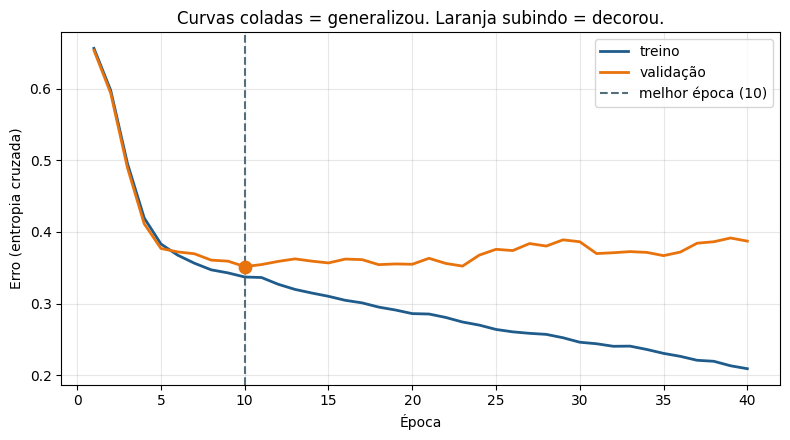

Na melhor época (10):
  erro de treino    = 0.3371
  erro de validação = 0.3517
  folga             = +0.0145

Folga pequena: os dois erros estão próximos.
A rede generalizou; o que ela aprendeu vale para pacientes novos.


In [9]:
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(hist_treino) + 1), hist_treino,
         label='treino', color='#1F5C8B', lw=2)
plt.plot(range(1, len(hist_val) + 1), hist_val,
         label='validação', color='#E8720C', lw=2)
plt.axvline(melhor_epoca, ls='--', color='#546E7A', lw=1.5,
            label=f'melhor época ({melhor_epoca})')
plt.scatter([melhor_epoca], [melhor_val], color='#E8720C', s=80, zorder=5)

plt.xlabel('Época')
plt.ylabel('Erro (entropia cruzada)')
plt.title('Curvas coladas = generalizou. Laranja subindo = decorou.')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

perda_treino_melhor = hist_treino[melhor_epoca - 1]
folga = melhor_val - perda_treino_melhor

print(f'Na melhor época ({melhor_epoca}):')
print(f'  erro de treino    = {perda_treino_melhor:.4f}')
print(f'  erro de validação = {melhor_val:.4f}')
print(f'  folga             = {folga:+.4f}')
print()
if folga > 0.15:
    print('Folga grande: a rede vai bem melhor no treino do que na validação.')
    print('Isso é SOBREAJUSTE — ela decorou parte dos pacientes de treino.')
else:
    print('Folga pequena: os dois erros estão próximos.')
    print('A rede generalizou; o que ela aprendeu vale para pacientes novos.')

---
## Passo 8 — Inferência no teste (abrindo o cofre)

**Inferência** = usar a rede já treinada para prever casos novos.

Só agora tocamos no conjunto de teste. Até este ponto do notebook ele não influenciou **nada**: nem o WOE, nem a mediana da imputação, nem a média da padronização, nem a escolha da época de parada. É por isso que o número que sai daqui é uma estimativa honesta de como a rede se comportaria com pacientes que chegassem amanhã.

Duas linhas importantes:
- **`modelo.eval()`** — desliga o dropout e avisa que estamos avaliando;
- **`torch.no_grad()`** — desliga o cálculo de derivadas, economizando memória.

E então convertemos a saída em decisão:
1. `torch.sigmoid(logit)` espreme o número para o intervalo 0 a 1 → vira **probabilidade**;
2. se a probabilidade for ≥ 0,5, decidimos pela classe 1 (com doença).

> **Regra de ouro:** rodou o teste, acabou. Se você olhar o resultado, mudar a arquitetura e rodar de novo, o teste virou validação — e você perdeu sua estimativa imparcial. Ajustes se fazem contra a validação.


In [10]:
modelo.eval()

with torch.no_grad():
    logits = modelo(X_test_t)             # saída crua da rede
    probs  = torch.sigmoid(logits)        # vira probabilidade (0 a 1)
    preds  = (probs >= 0.5).float()       # vira decisão (0 ou 1)

y_real    = y_test_t.numpy().ravel()      # o que era verdade
y_prev    = preds.numpy().ravel()         # o que a rede decidiu
prob_prev = probs.numpy().ravel()         # o quão confiante ela estava

print(f'{len(y_real)} pacientes no conjunto de teste')
print(f'  realmente com doença : {int(y_real.sum())}')
print(f'  a rede apontou       : {int(y_prev.sum())}')

61 pacientes no conjunto de teste
  realmente com doença : 28
  a rede apontou       : 32


---
## A matriz de confusão — a base de tudo

Toda métrica de classificação nasce de **quatro números**. Para cada paciente do teste, comparamos o que era verdade com o que a rede decidiu:

| | | |
|---|---|---|
| **VP** — Verdadeiro Positivo | doente, a rede acertou | ✅ |
| **VN** — Verdadeiro Negativo | saudável, a rede acertou | ✅ |
| **FP** — Falso Positivo | saudável, mas a rede disse doente | ❌ *alarme falso* |
| **FN** — Falso Negativo | doente, mas a rede disse saudável | ❌ *o erro perigoso* |

> **Em medicina, FN e FP não têm o mesmo peso.** Um falso positivo gera um exame extra e um susto. Um **falso negativo manda para casa um paciente que está tendo um problema cardíaco**. Por isso, num contexto de triagem, aceitamos aumentar os FP para reduzir os FN.

---
## As métricas, uma a uma

### Acurácia = (VP + VN) / total
*"De todos os pacientes, que fração eu classifiquei certo?"*

É a mais intuitiva — e a mais **enganosa**. Imagine uma doença que atinge 1% da população: um modelo que responde "saudável" para todo mundo tem **99% de acurácia** e não serve para absolutamente nada, porque nunca encontra um doente sequer. É por isso que vamos substituí-la pelo relatório para classes desbalanceadas.

### Precisão (`pre`) = VP / (VP + FP)
*"Dos que eu apontei como doentes, quantos realmente estavam?"*

Mede a **confiabilidade do alarme**. Precisão baixa = o modelo grita "doente!" à toa. Importa quando agir custa caro (uma cirurgia, um bloqueio de cartão, um e-mail legítimo jogado no spam).

### Recall, ou Sensibilidade (`rec`) = VP / (VP + FN)
*"Dos que realmente estavam doentes, quantos eu consegui encontrar?"*

Mede a **capacidade de não deixar passar**. É a métrica mais importante em triagem médica: recall de 0,82 significa que **18% dos doentes foram mandados para casa**.

### Especificidade (`spe`) = VN / (VN + FP)
*"Dos saudáveis, quantos eu corretamente liberei?"*

É o espelho do recall, olhando para a classe negativa. Recall e especificidade juntos contam a história completa — sempre há um trade-off entre os dois.

### F1 = 2 × (pre × rec) / (pre + rec)
Média **harmônica** entre precisão e recall. Usa-se a harmônica, e não a simples, porque ela pune desequilíbrio: um modelo com precisão 1,0 e recall 0,0 teria média simples 0,5, mas F1 = 0. Só sobe se **as duas** forem boas.

### Média geométrica (`geo`) = √(rec × spe)
Equilíbrio entre acertar a classe positiva **e** a negativa. Se o modelo for excelente numa e péssimo na outra, a `geo` desaba — diferente da acurácia, que se deixa enganar pela classe majoritária.

### IBA — *Index of Balanced Accuracy* (`iba`)
Pega a `geo` e aplica um desconto proporcional à diferença entre recall e especificidade. Dois modelos com a mesma `geo` recebem notas diferentes: quem trata as duas classes de forma equilibrada fica com IBA maior.

### Suporte (`sup`)
Não é métrica: é só **quantos pacientes reais** existem de cada classe no teste. Serve para saber se uma métrica foi calculada sobre 500 casos ou sobre 3.

### AUC-ROC
*"Se eu sortear um doente e um saudável ao acaso, qual a chance de o modelo dar uma nota mais alta ao doente?"*

Esta é diferente de todas as anteriores: ela **não depende do limiar de 0,5**. Enquanto as outras avaliam as decisões já tomadas, a AUC avalia o **ranqueamento** — a capacidade de ordenar os pacientes por risco.

| AUC | Leitura |
|---|---|
| 0,5 | igual a jogar moeda |
| 0,6 – 0,7 | fraco |
| 0,7 – 0,8 | aceitável |
| 0,8 – 0,9 | bom |
| > 0,9 | excelente (e hora de desconfiar de vazamento de dados) |


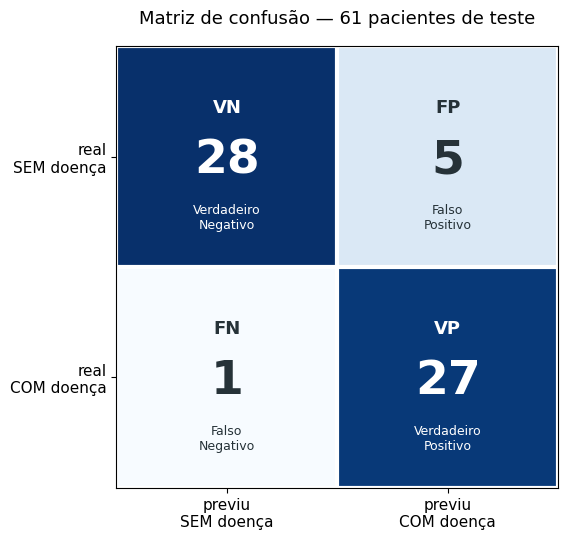

Acurácia       = (VP+VN)/total = (27+28)/61 = 0.902
Precisão       = VP/(VP+FP)    = 27/32     = 0.844
Recall         = VP/(VP+FN)    = 27/28     = 0.964
Especificidade = VN/(VN+FP)    = 28/33     = 0.848
F1             = 2·pre·rec/(pre+rec)  = 0.900
Média geom.    = sqrt(rec × spe)      = 0.905
AUC-ROC        = área sob a curva ROC = 0.970

LEITURA EM PALAVRAS
A rede apontou 32 pacientes como doentes; 27 realmente estavam.
   -> precisão 84.4%: 5 alarme(s) falso(s).

Havia 28 pacientes doentes no teste. A rede encontrou 27
   e DEIXOU 1 PASSAR(EM).
   -> recall 96.4%. Cada um desses 1 iria para casa sem tratamento.

Dos 33 pacientes saudáveis, 28 foram corretamente liberados.
   -> especificidade 84.8%.

OK: recall >= especificidade, perfil adequado para triagem.


In [11]:
cm = confusion_matrix(y_real, y_prev)
vn, fp, fn, vp = cm.ravel()
total = cm.sum()

# ---------------------------- o desenho ----------------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap='Blues')

siglas = [['VN', 'FP'], ['FN', 'VP']]
nomes  = [['Verdadeiro\nNegativo', 'Falso\nPositivo'],
          ['Falso\nNegativo', 'Verdadeiro\nPositivo']]

for i in range(2):
    for j in range(2):
        cor = 'white' if cm[i, j] > cm.max() * 0.6 else '#263238'
        ax.text(j, i - 0.22, siglas[i][j], ha='center', va='center',
                fontsize=13, fontweight='bold', color=cor)
        ax.text(j, i + 0.02, str(cm[i, j]), ha='center', va='center',
                fontsize=34, fontweight='bold', color=cor)
        ax.text(j, i + 0.28, nomes[i][j], ha='center', va='center',
                fontsize=9, color=cor)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['previu\nSEM doença', 'previu\nCOM doença'], fontsize=11)
ax.set_yticklabels(['real\nSEM doença', 'real\nCOM doença'], fontsize=11)
ax.set_title(f'Matriz de confusão — {total} pacientes de teste', fontsize=13, pad=16)
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=3)
ax.tick_params(which='minor', length=0)
plt.tight_layout()
plt.show()

# ------------------- as métricas, saindo das fórmulas -------------------
acuracia      = (vp + vn) / total
precisao      = vp / (vp + fp) if (vp + fp) else 0.0
recall        = vp / (vp + fn) if (vp + fn) else 0.0
especificidad = vn / (vn + fp) if (vn + fp) else 0.0
f1            = 2 * precisao * recall / (precisao + recall) if (precisao + recall) else 0.0
geo           = np.sqrt(recall * especificidad)
auc           = roc_auc_score(y_real, prob_prev)

print(f'Acurácia       = (VP+VN)/total = ({vp}+{vn})/{total} = {acuracia:.3f}')
print(f'Precisão       = VP/(VP+FP)    = {vp}/{vp + fp}     = {precisao:.3f}')
print(f'Recall         = VP/(VP+FN)    = {vp}/{vp + fn}     = {recall:.3f}')
print(f'Especificidade = VN/(VN+FP)    = {vn}/{vn + fp}     = {especificidad:.3f}')
print(f'F1             = 2·pre·rec/(pre+rec)  = {f1:.3f}')
print(f'Média geom.    = sqrt(rec × spe)      = {geo:.3f}')
print(f'AUC-ROC        = área sob a curva ROC = {auc:.3f}')

# ------------------- a mesma coisa, em português -------------------
print()
print('=' * 62)
print('LEITURA EM PALAVRAS')
print('=' * 62)
print(f'A rede apontou {vp + fp} pacientes como doentes; {vp} realmente estavam.')
print(f'   -> precisão {precisao:.1%}: {fp} alarme(s) falso(s).')
print()
print(f'Havia {vp + fn} pacientes doentes no teste. A rede encontrou {vp}')
print(f'   e DEIXOU {fn} PASSAR(EM).')
print(f'   -> recall {recall:.1%}. Cada um desses {fn} iria para casa sem tratamento.')
print()
print(f'Dos {vn + fp} pacientes saudáveis, {vn} foram corretamente liberados.')
print(f'   -> especificidade {especificidad:.1%}.')
print()
if recall < especificidad:
    print('ATENÇÃO: recall < especificidade. A rede está mais confortável dizendo')
    print('"saudável" do que "doente" — o oposto do desejável numa triagem médica.')
else:
    print('OK: recall >= especificidade, perfil adequado para triagem.')

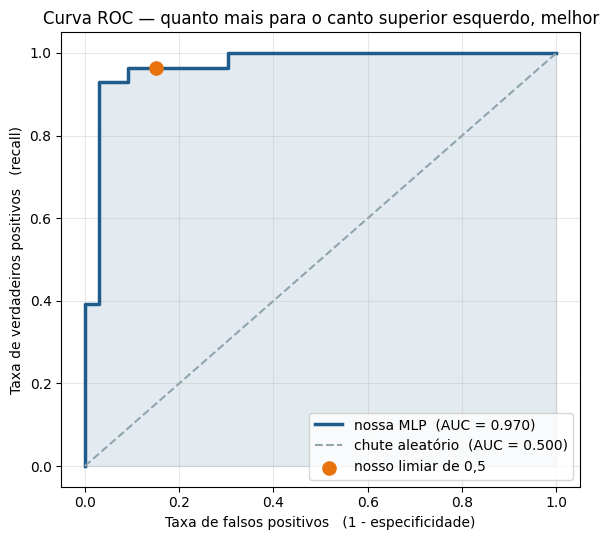

In [12]:
# A curva ROC varre TODOS os limiares possíveis (não só o 0,5) e mostra,
# para cada um, o par (falsos positivos, verdadeiros positivos).
fpr, tpr, limiares = roc_curve(y_real, prob_prev)

plt.figure(figsize=(6, 5.5))
plt.plot(fpr, tpr, lw=2.5, color='#1F5C8B', label=f'nossa MLP  (AUC = {auc:.3f})')
plt.fill_between(fpr, tpr, alpha=0.12, color='#1F5C8B')
plt.plot([0, 1], [0, 1], '--', lw=1.5, color='#90A4AE',
         label='chute aleatório  (AUC = 0.500)')
plt.scatter([fp / (vn + fp)], [vp / (vp + fn)], s=90, zorder=5,
            color='#E8720C', label='nosso limiar de 0,5')

plt.xlabel('Taxa de falsos positivos   (1 - especificidade)')
plt.ylabel('Taxa de verdadeiros positivos   (recall)')
plt.title('Curva ROC — quanto mais para o canto superior esquerdo, melhor')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Requer a biblioteca imbalanced-learn. O -q deixa a instalação silenciosa.
!pip install -q imbalanced-learn
from imblearn.metrics import classification_report_imbalanced

print(classification_report_imbalanced(
    y_real, y_prev,
    target_names=['sem doença', 'com doença'],
    digits=3,
))

print('Legenda das colunas:')
print('  pre = precisão        rec = recall / sensibilidade')
print('  spe = especificidade  f1  = média harmônica de pre e rec')
print('  geo = média geométrica de rec e spe')
print('  iba = índice de acurácia balanceada')
print('  sup = suporte (nº real de pacientes da classe)')

                   pre       rec       spe        f1       geo       iba       sup

 sem doença      0.966     0.848     0.964     0.903     0.905     0.809        33
 com doença      0.844     0.964     0.848     0.900     0.905     0.828        28

avg / total      0.910     0.902     0.911     0.902     0.905     0.817        61

Legenda das colunas:
  pre = precisão        rec = recall / sensibilidade
  spe = especificidade  f1  = média harmônica de pre e rec
  geo = média geométrica de rec e spe
  iba = índice de acurácia balanceada
  sup = suporte (nº real de pacientes da classe)


### Lendo a tabela linha por linha

|  | pre | rec | spe | f1 | geo | iba | sup |
|---|---|---|---|---|---|---|---|
| sem doença | 0,966 | 0,848 | 0,964 | 0,903 | 0,905 | 0,809 | 33 |
| com doença | 0,844 | 0,964 | 0,848 | 0,900 | 0,905 | 0,828 | 28 |
| avg / total | 0,910 | 0,902 | 0,911 | 0,902 | 0,905 | 0,817 | 61 |

---

#### 1. As duas linhas são o **mesmo modelo**, visto de dois lados

Este é o ponto que mais confunde quem lê o relatório pela primeira vez. Não são dois classificadores: é um só, avaliado uma vez tomando `sem doença` como classe positiva, e outra vez tomando `com doença`.

Por isso as colunas se espelham:

| | recall | especificidade |
|---|---|---|
| sem doença | **0,848** | 0,964 |
| com doença | 0,964 | **0,848** |

O que é *recall* de uma classe é *especificidade* da outra. Os números se cruzam na diagonal — se isso não acontecer no seu relatório, há erro em algum lugar.

#### 2. Dá para reconstruir a matriz de confusão só com esta tabela

O suporte diz que havia **33 saudáveis e 28 doentes**. A partir dos recalls:

- `rec` da classe *com doença* = 0,964 → 0,964 × 28 = **27 doentes encontrados** → sobra **1 falso negativo**
- `rec` da classe *sem doença* = 0,848 → 0,848 × 33 = **28 saudáveis liberados** → sobram **5 falsos positivos**

| | previu sem | previu com |
|---|---:|---:|
| **real sem doença** | VN = 28 | FP = 5 |
| **real com doença** | FN = 1 | VP = 27 |

Conferindo com as precisões: 27/(27+5) = 0,844 ✓ e 28/(28+1) = 0,966 ✓. Bate.

#### 3. A precisão de 0,966 é o número mais importante para triagem

A precisão da classe *sem doença* tem um nome próprio em medicina: **valor preditivo negativo**. Ela responde a pergunta que o paciente realmente faz:

> *"O exame deu negativo. Posso confiar?"*

Resposta: em 29 pacientes que a rede liberou, **28 estavam mesmo bem**. É o número que sustenta a decisão de mandar alguém para casa — e é justamente o que a acurácia global de 90% não deixa ver.

Do outro lado, a precisão de *com doença* (0,844) é o **valor preditivo positivo**: dos 32 encaminhados para investigação, 27 tinham de fato a doença.

#### 4. O perfil do modelo: erra para o lado seguro

Compare, dentro da linha `com doença`:

- recall **0,964** — pega quase todos os doentes
- precisão **0,844** — mas levanta 5 alarmes falsos

A rede está **mais disposta a errar apontando doença do que deixando passar**. Para triagem cardíaca, é exatamente o comportamento desejado: o custo de um exame extra é incomparavelmente menor que o de um infarto não diagnosticado.

Na versão anterior do notebook o perfil era o oposto (recall 0,821 contra especificidade 0,875) — a rede preferia dizer "saudável".

#### 5. Por que `geo` é igual nas duas linhas e `iba` não

A **média geométrica** é `√(rec × spe)`. Como recall e especificidade trocam de lugar entre as linhas, o produto é o mesmo — e a `geo` sai idêntica (0,905). É uma métrica **simétrica**: mede o equilíbrio do modelo como um todo, sem tomar partido de classe.

Já o **IBA** parte da `geo` e aplica um ajuste pela *dominância* (`rec − spe`):

```
IBA = (1 + α · (rec − spe)) × geo²        com α = 0,1
```

- classe *com doença*: dominância = 0,964 − 0,848 = **+0,116** → IBA = 1,0116 × 0,819 = **0,828**
- classe *sem doença*: dominância = 0,848 − 0,964 = **−0,116** → IBA = 0,9884 × 0,819 = **0,809**

O IBA **premia a classe em que o modelo tem recall maior que especificidade**. A diferença de 0,019 entre as duas linhas é a medida exata do viés do modelo em favor da detecção de doença.

#### 6. A linha `avg / total` é ponderada pelo suporte

Não é média simples. Para a precisão:

```
(0,966 × 33 + 0,844 × 28) / 61 = 0,910
```

Como as classes aqui são quase equilibradas (33 contra 28), a média ponderada fica próxima da simples. **Num problema desbalanceado, essa linha engana**: com 95% de uma classe, ela reflete quase só o desempenho na majoritária. Nesses casos, olhe as linhas individuais, ou a `geo`.

---

### O que esta tabela **não** mostra

| Ausente | Por que importa |
|---|---|
| **AUC** | todas as métricas acima dependem do limiar de 0,5; a AUC não |
| **Contagens absolutas** | "0,964" soa abstrato; "1 paciente perdido" não |
| **Incerteza** | com 61 casos, o intervalo de confiança de 90% é de grosso modo ±7 pontos |

Sobre a última linha: **aquele único falso negativo poderia virar 3 ou 4 só trocando a semente aleatória**. Um resultado sobre 61 pacientes é uma indicação, não uma conclusão. Para reportar isso como resultado de trabalho, use a validação cruzada do exercício 6 e informe média ± desvio.


---
## Como ler o que acabou de sair

A célula acima já imprime a **leitura em palavras** com os seus números. Use esta seção como guia para transformar qualquer relatório de métricas em decisão.

### O roteiro de leitura, na ordem

**1. Olhe primeiro os FN, não a acurácia.**
Em triagem médica, cada falso negativo é um paciente doente mandado para casa. Se houver 5 FN entre 28 doentes, o titular da notícia não é "82% de recall" — é "5 pessoas passaram despercebidas".

**2. Compare recall com especificidade.**
Se a especificidade for maior, o modelo tem viés para dizer "saudável". Isso acontece naturalmente quando a classe negativa é maior, e é o oposto do que se quer numa triagem.

**3. Veja se precisão e recall estão desequilibrados.**
Precisão alta com recall baixo = modelo tímido, só aponta os casos óbvios. Recall alto com precisão baixa = modelo alarmista. O F1 resume os dois, mas esconde qual dos dois está ruim — sempre olhe os dois separados antes.

**4. Use a AUC para comparar modelos, não para decidir casos.**
A AUC avalia o **ranqueamento** e não depende do limiar. Serve para responder "a rede A é melhor que a B?". Não serve para responder "o que faço com este paciente?" — isso depende do limiar escolhido.

---
## O trade-off do limiar

Todas as métricas acima, **exceto a AUC**, dependem da linha de corte de 0,5. Volte na célula de inferência e experimente:

```python
preds = (probs >= 0.5).float()     # limiar padrão
preds = (probs >= 0.3).float()     # mais sensível: "na dúvida, encaminhe"
```

| | Efeito ao **baixar** o limiar | Por quê |
|---|---|---|
| Falsos negativos (doentes perdidos) | ⬇️ **diminuem** | é o objetivo da mudança |
| Recall / sensibilidade | ⬆️ **sobe** | encontra mais doentes |
| Falsos positivos (exames à toa) | ⬆️ **aumentam** | o preço a pagar |
| Especificidade | ⬇️ **cai** | libera menos saudáveis |
| Precisão | ⬇️ **cai** | mais alarmes falsos entre os apontados |
| **AUC** | **não muda** | não depende do limiar |

A AUC não se move porque o **ranqueamento** dos pacientes continua o mesmo — mudou apenas onde traçamos a linha.

Na curva ROC, o ponto laranja marca o limiar atual. **Escolher o limiar é escolher um ponto sobre aquela curva** — e é uma decisão de negócio, não de estatística.

> **Numa aplicação real, o limiar sai da validação, nunca do teste.** Escolha o corte que atinge o recall exigido pelo protocolo clínico usando `X_val`, e só então meça o desempenho final no teste. Ajustar o limiar olhando o teste é a mesma família de erro do vazamento de dados.

> **Não existe "a melhor métrica".** Existe a métrica adequada ao custo do erro no seu problema. Em triagem cardíaca, priorize **recall**. Em bloqueio automático de cartão, priorize **precisão**. Para comparar modelos de forma neutra, use **AUC** ou **média geométrica**.


### Olhando paciente por paciente

Repare na coluna `probabilidade`: valores perto de 0,5 são os casos em que a rede ficou **em dúvida**. São justamente esses que merecem atenção humana.

In [14]:
resultado = pd.DataFrame({
    'real':          y_real.astype(int),
    'probabilidade': prob_prev.round(3),
    'previsto':      y_prev.astype(int),
})
resultado['acertou'] = resultado['real'] == resultado['previsto']

resultado.head(15)

,real,probabilidade,previsto,acertou
0,0,0.352,0,True
1,0,0.736,1,False
2,0,0.030,0,True
3,0,0.031,0,True
4,0,0.489,0,True
5,0,0.022,0,True
6,0,0.074,0,True
7,0,0.166,0,True
8,1,0.702,1,True
9,0,0.214,0,True


---
## O que mudou em relação à versão ingênua

| | Versão anterior | Esta versão |
|---|---|---|
| Fonte dos dados | CSV **já codificado** | dados **brutos** |
| Ordem | codificar → dividir | **dividir → codificar** |
| Ajuste do WOE | sobre os 297 pacientes | só sobre o treino |
| Faltantes | 6 linhas descartadas | imputação pela mediana do treino |
| Conjuntos | treino + teste | treino + **validação** + teste |
| Fim do treino | 100 épocas fixas | **parada antecipada** pela validação |
| Regularização | nenhuma | dropout + `weight_decay` |
| Métrica honesta? | **não** (vazamento) | **sim** |

### E o desempenho, melhorou ou piorou?

Na execução de referência, a acurácia **subiu** de 85% para 90%, e os falsos negativos caíram de 5 para 1.

Isso costuma surpreender: *"não era para piorar, já que tiramos o vazamento?"*

Não necessariamente — e entender por quê é mais valioso que o número em si. **Três coisas mudaram ao mesmo tempo**, e elas puxam para lados opostos:

| Mudança | Efeito esperado no desempenho |
|---|---|
| Remoção do vazamento | ⬇️ piora (a nota estava inflada) |
| Dropout + `weight_decay` + parada antecipada | ⬆️ melhora (menos sobreajuste) |
| Divisão diferente dos dados | ↔️ ruído |

O modelo anterior estava **severamente sobreajustado** — erro de treino em 0,0043 significa que ele tinha decorado os pacientes de treino. O ganho de generalização trazido pela regularização foi maior que a perda do vazamento.

Além disso, o vazamento do WOE aqui é **mais fraco do que parece**: com 2 a 4 categorias por coluna, a informação do rótulo se dilui num agregado por categoria, e não vaza linha a linha como aconteceria com um encoder de alta cardinalidade (CPF, CEP, id de produto).

> **A lição não é "vazamento não importa".** É que remover o vazamento torna a medida **confiável**, não necessariamente menor. Uma medida com vazamento é uma medida que você não pode usar para decidir nada — independente de ser alta ou baixa.

E há uma armadilha estatística aqui: com **61 pacientes de teste, cada acerto ou erro vale 1,6 ponto percentual**. A diferença entre 85% e 90% são cerca de 3 pacientes. Comparar dois modelos com uma única divisão desse tamanho é frágil — é exatamente para isso que serve a validação cruzada do exercício 6.

---
## Levando para produção

O que falta para isto virar um serviço de verdade:

**1. Salvar as duas peças, juntas.**

```python
import joblib
joblib.dump(preprocessador, 'preprocessador.joblib')
torch.save(modelo.state_dict(), 'modelo.pt')
```

O `preprocessador` guarda os WOE, as medianas e as médias do dia do treino. Sem ele, o servidor recalcularia essas estatísticas com os dados que chegarem — e as previsões mudariam sozinhas ao longo do tempo. Esse é o bug de ML mais comum e mais difícil de diagnosticar.

**2. Validação cruzada em vez de uma divisão única.**
Com 303 pacientes, trocar o `random_state` muda bastante o resultado. Um `StratifiedKFold` de 5 dobras dá uma estimativa muito mais estável — reporte média e desvio, não um número solto.

**3. Monitorar o *drift*.**
A distribuição dos pacientes muda com o tempo (novo equipamento, nova população). Vale acompanhar as estatísticas das entradas em produção e comparar com as do treino.

**4. Definir o limiar com o time clínico.**
Não é escolha do cientista de dados. A pergunta correta é: *"quantos falsos positivos vocês toleram para não perder nenhum caso?"*

---
## Exercícios

1. Rode duas vezes trocando o `SEED` para `7` e depois `123`. Quanto o AUC varia? O que isso diz sobre confiar numa única divisão treino/teste?
2. Remova o `Dropout` e o `weight_decay`. O que acontece com a distância entre as curvas azul e laranja?
3. Aumente a rede para `64` e `32` neurônios. A parada antecipada dispara mais cedo ou mais tarde? Por quê?
4. Troque o limiar para `0.3` **usando a validação** e só depois avalie no teste. Compare os falsos negativos.
5. Substitua o `WOEEncoder` por um `OneHotEncoder` dentro do mesmo pipeline. O AUC melhora? A dimensionalidade aumenta quanto?
6. Implemente validação cruzada com `StratifiedKFold(n_splits=5)` e reporte média ± desvio do AUC.
7. **O experimento do vazamento — isolando a variável:** mantenha dropout, `weight_decay` e parada antecipada exatamente como estão, e mude **só uma coisa**: ajuste o `preprocessador` com `fit_transform(X_raw, y_raw)` antes de dividir. Agora a única diferença é o vazamento. Repita com 5 sementes diferentes e compare as médias de AUC. Essa é a única forma honesta de medir o tamanho do efeito.
